# Advección 1D

Santiago Andrés Acosta Díaz


Al parecer, se trata de resolver el problema de la advección del campo magnético

$$
    \frac{\partial B}{\partial t} + v_0 \frac{\partial B}{\partial r} = 0
$$

Utilizando el esquema de _upwind_ 

$$
    B_i^{n+1} = B_i^n - C \left( B_i^n - B_{i-1}^n \right)
$$

con $C = \frac{v_0 \Delta t}{\Delta x} \le 1$ siendo una solución numérica estable. 


El ejercicio nos dá un código en python que modifiqué para hacer el análisis más sencillo.

In [19]:
import numpy as np
import matplotlib.pyplot as plt 

# Parámetros
N = 200
NTp = 200     # Pasos de tiempo
L = 1.0
v0 = 1.0
dx = L / N

# Voy a hacer esto una función para poder ver cosas sin tanta repetición
def system(dtp, NT = NTp, DNT = 25, pulse = lambda x: np.sin(2. * np.pi * x / L)):

    # Esto nos da el parámetro C
    dt = dtp * dx / v0
    C = (v0 * dt / dx)

    print(f"Ejecución con C = {C}")

    # Creamos un histórico de B para ver la evolución
    Bhist = list()
    iterhist = list()
    
    # Malla
    x = np.linspace(0, L, N, endpoint=False)
    B = pulse(x)
    
    # Iteración
    for count in range(NT+1):
        
        bw = B - np.roll(B, 1)
        B += -C * bw

        if count % DNT == 0:
            Bhist.append(B.copy())
            iterhist.append(count)
            
    # Hacemos los plots
    plt.figure()

    for i, B in enumerate(Bhist):
        plt.plot(x, B, label = f"iter {iterhist[i]}", lw = 1.5, alpha = 0.7)

    plt.legend()
    plt.grid()
    plt.title(f"B profile with C = {C}")
    plt.ylabel("B")
    plt.xlabel("x")
    plt.show()

## Perfil de la onda

Ejecución con C = 0.4


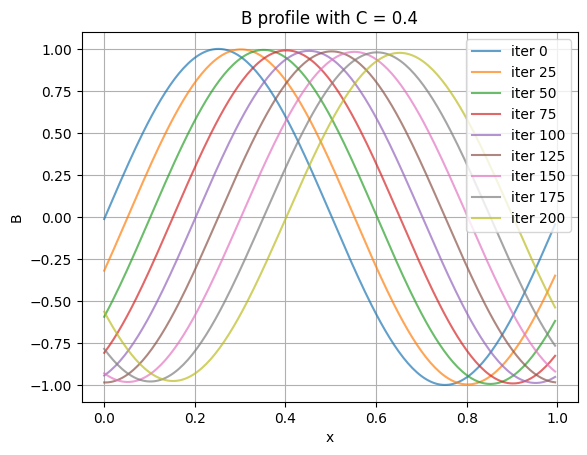

In [20]:
system(0.4)

Podemos ver que, en general, considerando este valor de $C$ y las pocas iteraciones que tenemos, la onda se desplaza en el tiempo hacia la derecha, cosa que a priori deberíamos esperar. Algo a notar es que la amplitud a medida que la simulación transcurre disminuye, así sea muy ligeramente, esto es posiblemente debido al amortiguamiento artifical introducido por el upwind. Esto lo notamos mejor si simulamos más tiempo.

Ejecución con C = 0.4


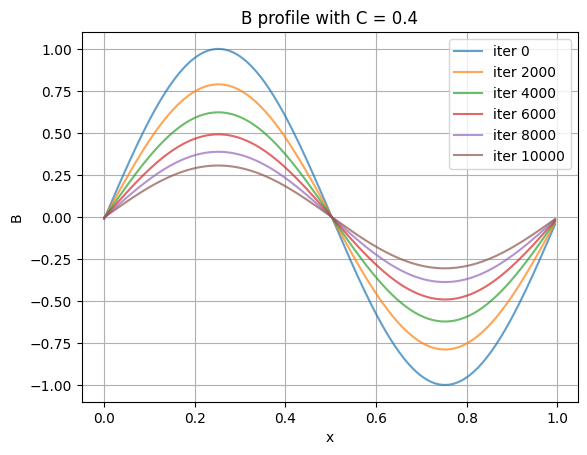

In [34]:
system(0.4, 10000, 2000)

Aquí, estoy ploteando intervalos de tiempo que justamente están en fase, esto para mostrar mejor cómo se ve este amortiguamiento.

## Diferentes CLF

Ahora, revisemos qué ocurre para el mismo sistema con diferentes CLF

Ejecución con C = 0.01


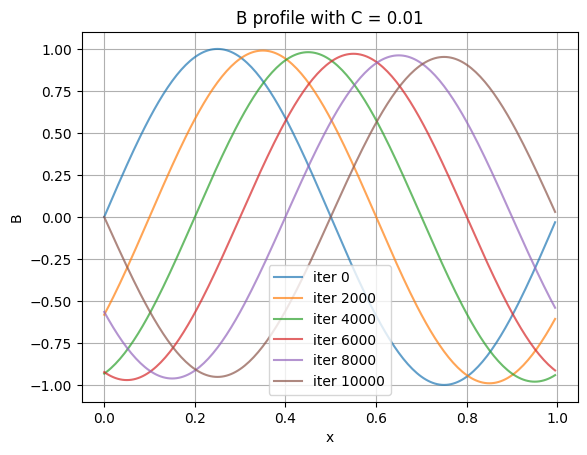

In [46]:
system(0.01, 10000, 2000)

Para un valor de $C$ más pequeño, podemos ver, primero, que el tiempo simulado es menos (por lo que el $dt$ disminuye), pero una consecuencia interesante es que la amortiguación parece disminuir: podemos comparar la línea marron de esta gráfica con la línea naranja del gráfico anterior (alrededor del mismo orden de magnitud en tiempo simulado), y podemos ver que, con este valor de $C < C_{prev}$, el amortiguamiento es mucho menor.

Ejecución con C = 0.9000000000000001


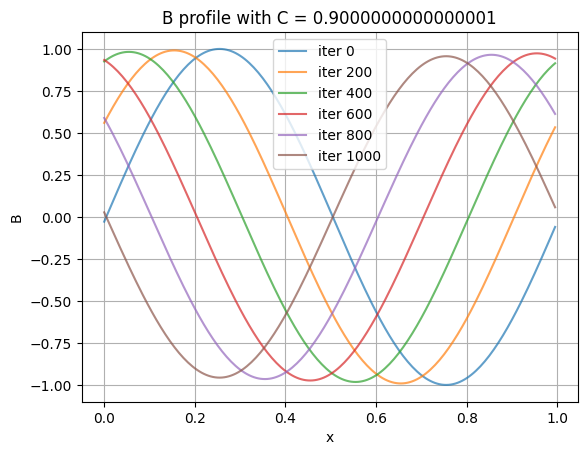

In [55]:
system(0.9, 1000, 200)

Si $C \to 1$, realmente vemos un comportamiento, a priori, similar al caso donde $C \to 0$, lo cual no me puedo explicar.

Ejecución con C = 1.1


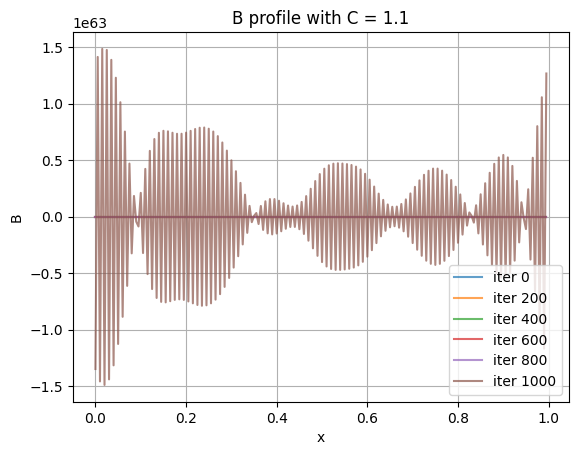

In [56]:
system(1.1, 1000, 200)

Y si $C>1$, vemos que se rompe por completo la estabilidad numérica del sistema, cosa que esperábamos.


Por último, revisamos el comportamiento con un pulso gaussiano

In [61]:
def gaussian(x, sigma = 0.1, mu = 0.5):
    return (1. / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

Ejecución con C = 0.01


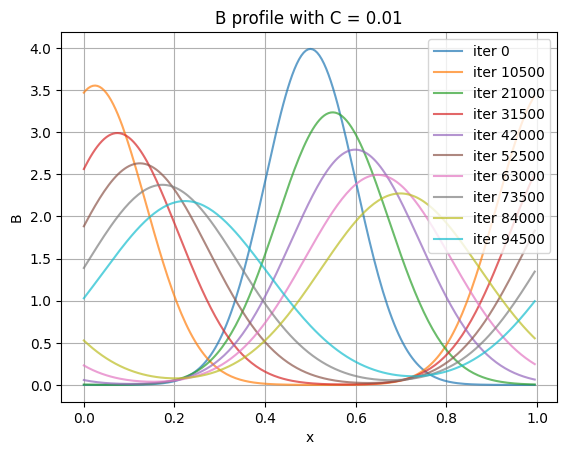

In [73]:
system(0.01, 100000, 10500, pulse = gaussian)

Vemos tanto que el pulso se desplaza a medida que transcurre el tiempo, y también la varianza que lo define crece, haciendo que el pulso se "difunda" en el espacio.